In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data\\student_placement_synthetic.csv')
df.columns

Index(['branch', 'college_tier', 'cgpa', 'backlogs', 'coding_skills',
       'dsa_score', 'aptitude_score', 'communication_skills', 'ml_knowledge',
       'system_design', 'internships', 'projects_count', 'certifications',
       'hackathons', 'open_source_contributions', 'extracurriculars',
       'placement_status', 'salary_package_lpa'],
      dtype='str')

In [3]:
# value_counts will group the values based on data present in dataset
df['placement_status'].value_counts()

placement_status
1    68475
0    31525
Name: count, dtype: int64

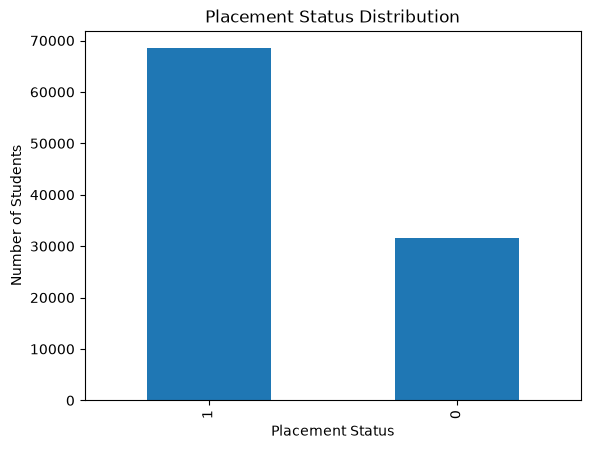

In [6]:
df['placement_status'].value_counts().plot(kind = 'bar')

plt.xlabel("Placement Status")
plt.ylabel("Number of Students")
plt.title("Placement Status Distribution")

plt.show()

In [7]:
df.dtypes

branch                           str
college_tier                     str
cgpa                         float64
backlogs                       int64
coding_skills                float64
dsa_score                    float64
aptitude_score               float64
communication_skills         float64
ml_knowledge                 float64
system_design                float64
internships                    int64
projects_count                 int64
certifications                 int64
hackathons                     int64
open_source_contributions      int64
extracurriculars               int64
placement_status               int64
salary_package_lpa           float64
dtype: object

In [8]:
df["placement_status"].unique()

array([1, 0])

In [10]:
df["placement_status"].value_counts()
# 1 --> Placed
# 0 --> Not Placed

placement_status
1    68475
0    31525
Name: count, dtype: int64

In [11]:
# columns containing numerical data
df.select_dtypes(include="number").columns

Index(['cgpa', 'backlogs', 'coding_skills', 'dsa_score', 'aptitude_score',
       'communication_skills', 'ml_knowledge', 'system_design', 'internships',
       'projects_count', 'certifications', 'hackathons',
       'open_source_contributions', 'extracurriculars', 'placement_status',
       'salary_package_lpa'],
      dtype='str')

In [12]:
# columns containing text data
df.select_dtypes(include="object").columns

C:\Users\devgi\AppData\Local\Temp\ipykernel_11468\3187655040.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").columns


Index(['branch', 'college_tier'], dtype='str')

In [13]:
# checking for duplicate values
df.duplicated().sum()

np.int64(0)

In [14]:
# checking for mising values
df.isnull().sum()

branch                           0
college_tier                     0
cgpa                             0
backlogs                         0
coding_skills                    0
dsa_score                        0
aptitude_score                   0
communication_skills             0
ml_knowledge                     0
system_design                    0
internships                      0
projects_count                   0
certifications                   0
hackathons                       0
open_source_contributions        0
extracurriculars                 0
placement_status                 0
salary_package_lpa           31525
dtype: int64

In [16]:
# calculate the average CGPA for each placement group
df.groupby('placement_status')['cgpa'].mean()
# Divide the students into groups according to placement status

placement_status
0    7.003297
1    7.299878
Name: cgpa, dtype: float64

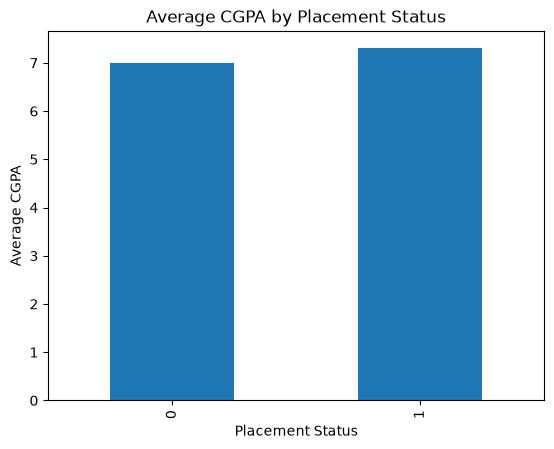

In [18]:
df.groupby('placement_status')['cgpa'].mean().plot(kind='bar')

plt.xlabel("Placement Status")
plt.ylabel("Average CGPA")
plt.title("Average CGPA by Placement Status")

plt.show()

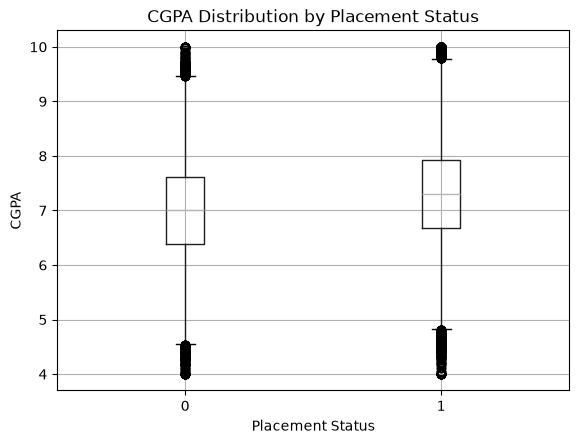

In [19]:
df.boxplot(column="cgpa", by="placement_status")

plt.xlabel("Placement Status")
plt.ylabel("CGPA")
plt.title("CGPA Distribution by Placement Status")

plt.suptitle("")

plt.show()

In [20]:
# boxplot helps us see:
# Median, Spread, Lower values, Higher values, Possible outliers

In [22]:
# placement rate by CGPA
df["cgpa_group"] = pd.cut(
    df["cgpa"],
    bins=[0, 6, 7, 8, 9, 10],
    labels=["<6", "6-7", "7-8", "8-9", "9-10"]
)
# We're converting individual CGPA values into groups

In [23]:
df.groupby("cgpa_group", observed=True)["placement_status"].mean()

cgpa_group
<6      0.563976
6-7     0.634564
7-8     0.708260
8-9     0.771313
9-10    0.834981
Name: placement_status, dtype: float64

In [24]:
# clear pattern: CGPA increases --> Placement rate increases


# The EDA shows a positive relationship between CGPA and placement rate. Placement rates increase consistently across higher CGPA groups

In [25]:
df.groupby("placement_status")["coding_skills"].mean()

placement_status
0    5.801843
1    6.084142
Name: coding_skills, dtype: float64

In [26]:
df['coding_skills'].describe()

count    100000.000000
mean          5.995147
std           1.496302
min           1.000000
25%           5.000000
50%           6.000000
75%           7.000000
max          10.000000
Name: coding_skills, dtype: float64

In [27]:
# Do placed students have higher coding skill scores than non-placed students?

df.groupby("placement_status")["coding_skills"].mean()

placement_status
0    5.801843
1    6.084142
Name: coding_skills, dtype: float64

In [29]:
# placement rate by number of internships
df.groupby("internships")["placement_status"].mean()

internships
0    0.627645
1    0.682844
2    0.731837
3    0.771841
Name: placement_status, dtype: float64

In [30]:
df.groupby("placement_status")["internships"].mean()

placement_status
0    0.956511
1    1.158817
Name: internships, dtype: float64

In [31]:
df.groupby("placement_status")[
    ["dsa_score", "aptitude_score", "communication_skills"]
].mean()

,dsa_score,aptitude_score,communication_skills
placement_status,,,
0,5.273294,64.192685,5.878052
1,5.605411,65.357820,6.042436


In [33]:
# correlation
# How strongly is each numerical variable associated with placement status?

df.select_dtypes(include="number").corr()["placement_status"].sort_values()

backlogs                    -0.058815
extracurriculars            -0.004807
system_design               -0.001583
ml_knowledge                 0.002097
open_source_contributions    0.022723
hackathons                   0.033315
aptitude_score               0.045146
communication_skills         0.051034
certifications               0.055636
projects_count               0.069900
dsa_score                    0.086594
coding_skills                0.087657
internships                  0.099967
cgpa                         0.148932
placement_status             1.000000
salary_package_lpa                NaN
Name: placement_status, dtype: float64

In [34]:
df.groupby("branch")["placement_status"].mean()

branch
CE          0.646648
CSE         0.713487
Chemical    0.645532
ECE         0.695763
EE          0.663497
IT          0.708932
ME          0.664057
Name: placement_status, dtype: float64

In [35]:
df.groupby("college_tier")["placement_status"].mean()

college_tier
Tier-1    0.830576
Tier-2    0.725608
Tier-3    0.600747
Name: placement_status, dtype: float64

In [ ]:
df.groupby("placement_status")[["dsa_score", "aptitude_score", "communication_skills"]
].mean()

,dsa_score,aptitude_score,communication_skills
placement_status,,,
0,5.273294,64.192685,5.878052
1,5.605411,65.357820,6.042436


In [39]:
# correaltion

df.select_dtypes(include="number").corr()["placement_status"].sort_values()

backlogs                    -0.058815
extracurriculars            -0.004807
system_design               -0.001583
ml_knowledge                 0.002097
open_source_contributions    0.022723
hackathons                   0.033315
aptitude_score               0.045146
communication_skills         0.051034
certifications               0.055636
projects_count               0.069900
dsa_score                    0.086594
coding_skills                0.087657
internships                  0.099967
cgpa                         0.148932
placement_status             1.000000
salary_package_lpa                NaN
Name: placement_status, dtype: float64

In [40]:
df.select_dtypes(include="number").corr()["placement_status"].sort_values()

backlogs                    -0.058815
extracurriculars            -0.004807
system_design               -0.001583
ml_knowledge                 0.002097
open_source_contributions    0.022723
hackathons                   0.033315
aptitude_score               0.045146
communication_skills         0.051034
certifications               0.055636
projects_count               0.069900
dsa_score                    0.086594
coding_skills                0.087657
internships                  0.099967
cgpa                         0.148932
placement_status             1.000000
salary_package_lpa                NaN
Name: placement_status, dtype: float64

In [41]:
# percentage of students from each branch got placed
df.groupby("branch")["placement_status"].mean()

branch
CE          0.646648
CSE         0.713487
Chemical    0.645532
ECE         0.695763
EE          0.663497
IT          0.708932
ME          0.664057
Name: placement_status, dtype: float64

In [42]:
# placement rate for each college tier
df.groupby("college_tier")["placement_status"].mean()

college_tier
Tier-1    0.830576
Tier-2    0.725608
Tier-3    0.600747
Name: placement_status, dtype: float64